## setup

In [1]:
# import stuff
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load data from folder
folder = Path('../data')

# filtered dataset
sold = pd.read_csv(folder / 'sold.csv', low_memory = False)

# unfiltered dataset, needed for eda questions
raw_sold = pd.read_csv(folder / 'unfiltered_sold.csv', low_memory = False)

## EDA

### dataset understanding
- check columns, data types, shape, head
- check property categories
- validate completeness

In [3]:
# ensuring datasets loaded in correctly (unfiltered)
print(raw_sold.shape)
raw_sold.head()

(666037, 82)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,...,NaN,NaN,92394,NaN,52320.0,NaN,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,...,NaN,NaN,93240,NaN,217364.0,NaN,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,2024-01-08,141500.0,...,NaN,NaN,92308,NaN,217800.0,NaN,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,2024-01-17,15000.0,...,NaN,NaN,93544,0.0,108883.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# ensuring datasets loaded in correctly (filtered)
print(sold.shape)
sold.head()

(448253, 82)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,NaN,NaN,NaN,NaN
4,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,2.0,NaN,95437,NaN,74487.6,NaN,NaN,NaN,NaN,NaN


In [5]:
sold.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [6]:
sold.dtypes

Flooring                         object
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
                                 ...   
MiddleOrJuniorSchoolDistrict    float64
BuyerAgentAOR                    object
ListAgentAOR                     object
OriginatingSystemName            object
OriginatingSystemSubName         object
Length: 82, dtype: object

### missing value analysis
- null-count summary table
- flag columns with >90% missing values
- which columns to drop or retain?

In [7]:
# null-ct summary table
sold_null_ct = sold.isnull().sum()
sold_null_pct = sold.isnull().mean() * 100

sold_null_summary = pd.DataFrame({
    'null ct': sold_null_ct,
    'null pct': sold_null_pct
})

sold_null_summary.sort_values(by = 'null pct', ascending = False).head(10)

,null ct,null pct
ElementarySchoolDistrict,448253,100.000000
TaxAnnualAmount,448253,100.000000
TaxYear,448253,100.000000
FireplacesTotal,448253,100.000000
BusinessType,448253,100.000000
CoveredSpaces,448253,100.000000
MiddleOrJuniorSchoolDistrict,448253,100.000000
AboveGradeFinishedArea,448253,100.000000
WaterfrontYN,447966,99.935974
BelowGradeFinishedArea,445596,99.407254


In [8]:
# find cols w >90% nulls
over_90 = sold_null_summary[sold_null_summary['null pct'] > 90]
print('Columns with over 90% nulls:', over_90.shape[0])
# output: (15,2)

# prepare list of cols to flag if they have >90% nulls
flag_over_90 = over_90.index.tolist()
flag_over_90

Columns with over 90% nulls: 15


['WaterfrontYN',
 'BasementYN',
 'FireplacesTotal',
 'AboveGradeFinishedArea',
 'TaxAnnualAmount',
 'BuilderName',
 'TaxYear',
 'BuildingAreaTotal',
 'ElementarySchoolDistrict',
 'CoBuyerAgentFirstName',
 'BelowGradeFinishedArea',
 'BusinessType',
 'CoveredSpaces',
 'LotSizeDimensions',
 'MiddleOrJuniorSchoolDistrict']

In [9]:
# what if we adjusted the threshold to >50% nulls
over_50 = sold_null_summary[sold_null_summary['null pct'] > 50]
print('Columns with over 50% nulls:', over_50.shape[0])
# output: 27

flag_over_50 = over_50.index.tolist()
flag_over_50

Columns with over 50% nulls: 27


['WaterfrontYN',
 'BasementYN',
 'CoListOfficeName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'TaxAnnualAmount',
 'ElementarySchool',
 'BuilderName',
 'SubdivisionName',
 'BuyerAgencyCompensationType',
 'BuyerAgencyCompensation',
 'TaxYear',
 'BuildingAreaTotal',
 'ElementarySchoolDistrict',
 'CoBuyerAgentFirstName',
 'BelowGradeFinishedArea',
 'BusinessType',
 'CoveredSpaces',
 'MiddleOrJuniorSchool',
 'HighSchool',
 'LotSizeDimensions',
 'MiddleOrJuniorSchoolDistrict',
 'OriginatingSystemName',
 'OriginatingSystemSubName']

In [10]:
# exclude core fields from flagged list if there are any
core_fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice',
               'LivingArea', 'LotSizeAcres', 'BedroomsTotal',
               'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

for field in core_fields:
    if field in flag_over_50:
        flag_over_50.remove(field)

# check if any flagged cols were removed
print(len(flag_over_50))
# 27

27


### numeric distribution summary
- ``.describe()``
- data visualizations (histograms, boxplots, percentile summaries)
- identify extreme outliers

In [11]:
numeric_fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 
                  'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 
                  'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

sold_summary = sold[numeric_fields].describe()
sold_summary

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,4.482490e+05,4.482530e+05,4.474260e+05,4.479990e+05,4.134540e+05,448241.000000,448183.000000,448253.000000,447851.000000
mean,1.183711e+06,1.143209e+06,1.228306e+06,1.904183e+03,6.218619e+01,3.205115,2.538445,37.326675,1978.622817
std,5.562462e+06,1.363551e+06,6.729387e+06,2.544772e+04,1.536924e+04,1.066597,1.130353,53.628852,26.320775
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.750000e+05,5.780000e+05,5.850000e+05,1.248000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.250000e+05,8.190000e+05,8.290000e+05,1.646000e+03,1.666000e-01,3.000000,2.000000,18.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.224000e+03,2.743000e-01,4.000000,3.000000,48.000000,1999.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2027.000000


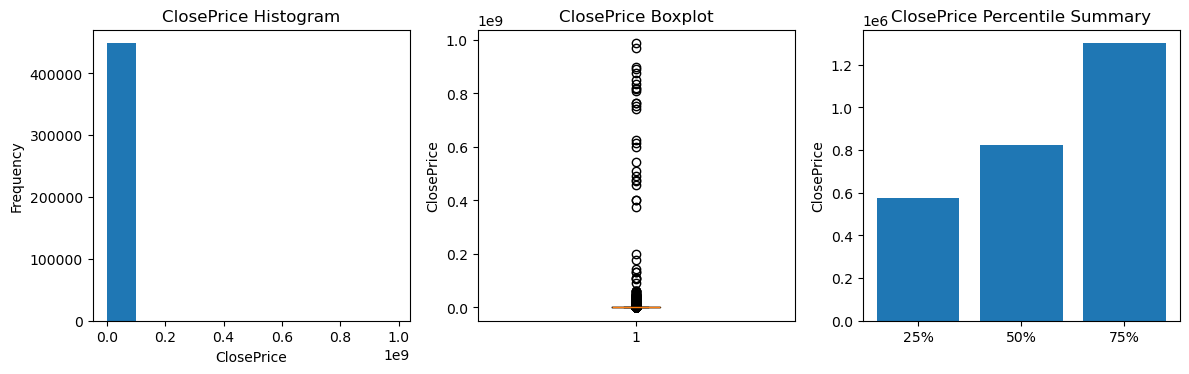

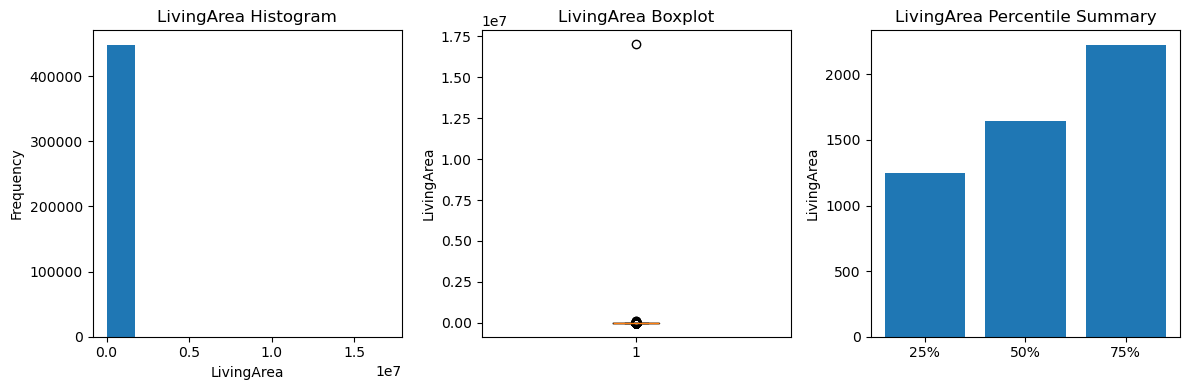

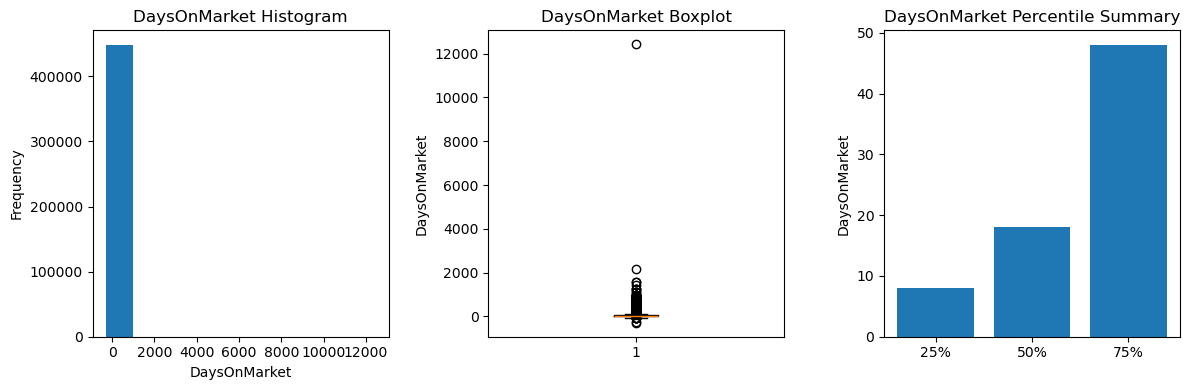

In [12]:
# visualizations for each numeric field (histograms, boxplots, and percentile summaries, and identify extreme outliers)
for col in ['ClosePrice', 'LivingArea', 'DaysOnMarket']:
    plt.figure(figsize=(12, 4))
    
    # histogram
    plt.subplot(1, 3, 1)
    plt.hist(sold[col].dropna())
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # boxplot
    plt.subplot(1, 3, 2)
    plt.boxplot(sold[col].dropna())
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)
    
    # percentile summary
    plt.subplot(1, 3, 3)
    percentiles = [25, 50, 75]
    vals = sold[col].quantile([p/100 for p in percentiles])
    plt.bar([f'{p}%' for p in percentiles], vals)
    plt.title(f'{col} Percentile Summary')
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

In [13]:
outliers = []

# find outliers
for field in numeric_fields:
    # focus on one column at a time, convert to numeric and drop nulls
    col = pd.to_numeric(sold[field], errors = 'coerce').dropna()

    # find lower, upper bounds and IQR
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    low_outliers = int((col < lower_bound).sum())
    high_outliers = int((col > upper_bound).sum())

    outliers.append({
        'field': field,
        'min': col.min(),
        'max': col.max(),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'low_outlier_ct': low_outliers,
        'high_outlier_ct': high_outliers,
        'total_outlier_ct': low_outliers + high_outliers,
        'outlier_pct': round((low_outliers + high_outliers) / len(col) * 100, 2)
    })

In [14]:
outlier_summary = pd.DataFrame(outliers)
outlier_summary

,field,min,max,lower_bound,upper_bound,low_outlier_ct,high_outlier_ct,total_outlier_ct,outlier_pct
0,ClosePrice,0.0,9.895000e+08,-512500.00000,2.387500e+06,0,33528,33528,7.48
1,ListPrice,525.0,1.375000e+08,-497500.00000,2.370500e+06,0,33840,33840,7.55
2,OriginalListPrice,0.0,1.390000e+09,-486000.00000,2.370000e+06,0,35116,35116,7.85
3,LivingArea,0.0,1.702132e+07,-216.00000,3.688000e+03,0,19578,19578,4.37
4,LotSizeAcres,0.0,7.810698e+06,-0.11145,5.057500e-01,0,64298,64298,15.55
5,BedroomsTotal,0.0,4.500000e+01,1.50000,5.500000e+00,16374,8153,24527,5.47
6,BathroomsTotalInteger,0.0,1.750000e+02,0.50000,4.500000e+00,347,20425,20772,4.63
7,DaysOnMarket,-288.0,1.243000e+04,-52.00000,1.080000e+02,8,34227,34235,7.64
8,YearBuilt,1776.0,2.027000e+03,1901.50000,2.057500e+03,1064,0,1064,0.24


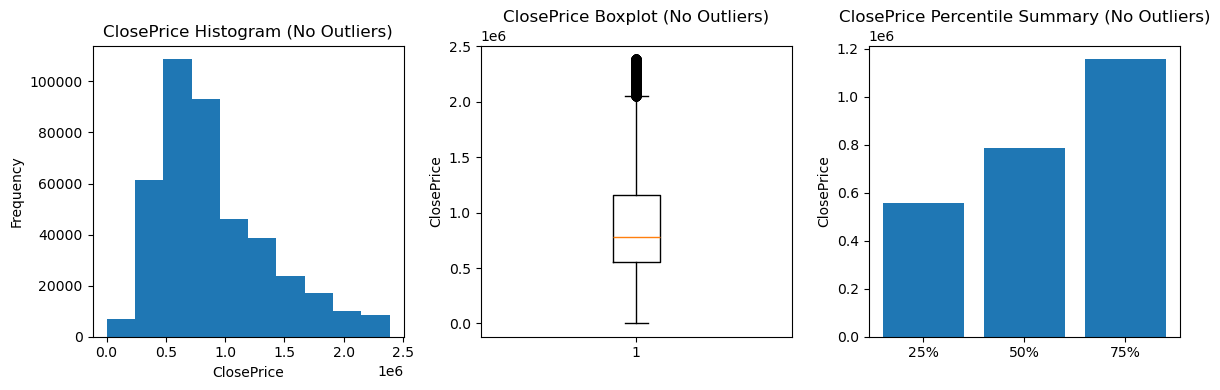

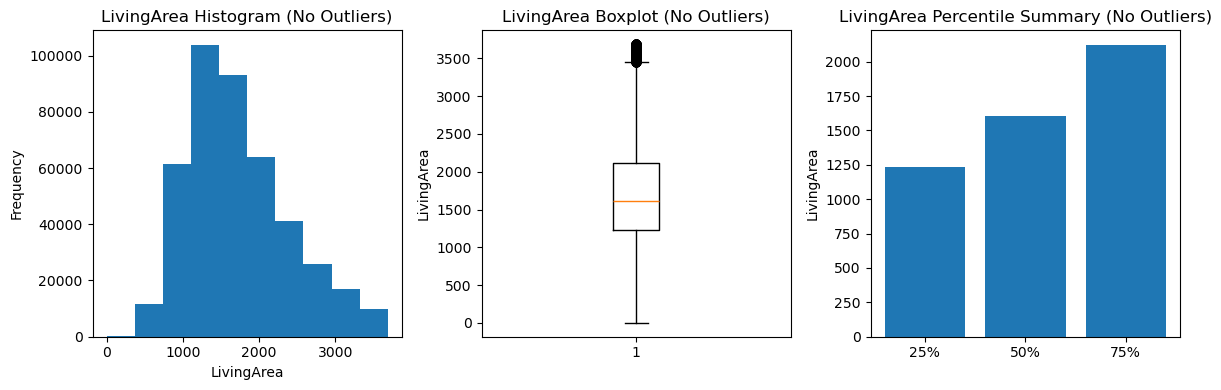

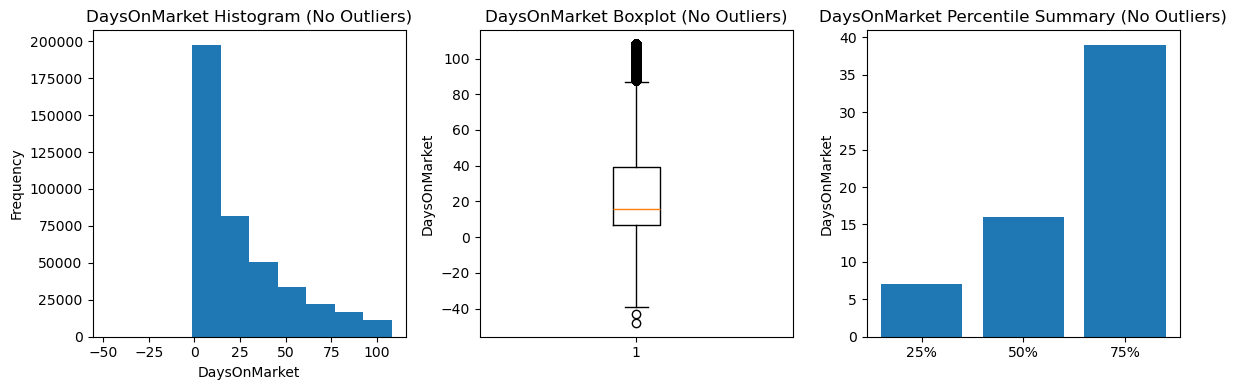

In [ ]:
# visualize without outliers
for col in ['ClosePrice', 'LivingArea', 'DaysOnMarket']:
    plt.figure(figsize=(12, 4))
    
    # filter out outliers
    q1 = sold[col].quantile(0.25)
    q3 = sold[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    filtered_col = sold[(sold[col] >= lower_bound) & (sold[col] <= upper_bound)][col]
    
    # histogram
    plt.subplot(1, 3, 1)
    plt.hist(filtered_col.dropna())
    plt.title(f'{col} Histogram (No Outliers)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # boxplot
    plt.subplot(1, 3, 2)
    plt.boxplot(filtered_col.dropna())
    plt.title(f'{col} Boxplot (No Outliers)')
    plt.ylabel(col)

    # percentile summary
    plt.subplot(1, 3, 3)
    percentiles = [25, 50, 75]
    vals = filtered_col.quantile([p/100 for p in percentiles])
    plt.bar([f'{p}%' for p in percentiles], vals)
    plt.title(f'{col} Percentile Summary (No Outliers)')
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

### save filtered dataset

In [17]:
# save filtered dataset as new csv
# sold.to_csv('../data/sold.csv', index = False)

## EDA questions

### What is the Residential vs other property type share?

In [18]:
property_pct = round(raw_sold['PropertyType'].value_counts(normalize = True) * 100, 2)
property_pct

PropertyType
Residential            67.30
ResidentialLease       22.89
Land                    3.22
ManufacturedInPark      2.70
ResidentialIncome       2.68
CommercialSale          0.62
CommercialLease         0.52
BusinessOpportunity     0.07
Name: proportion, dtype: float64

Looking back at the raw sold dataset, we can see that about 67.3% of property types are Residential homes where the remaining 32.7% are non-residential (which include property types like land, business, and commercial).

### What are the median & average close prices?

In [19]:
print('Median close price:', round(sold['ClosePrice'].median(), 2))
print('Average close price:', round(sold['ClosePrice'].mean(), 2))

Median close price: 825000.0
Average close price: 1183711.14


For the sold dataset, the median close price (825,000) is a lower value than the average (1,183,711), meaning that this column follows a right-skewed distribution. This is supported by the visualization generated earlier, without outliers, where there is a cluster of values on the left side and there is a right tail for higher values.

### Look at days on market distribution

In [20]:
sold['DaysOnMarket'].describe()

count    448253.000000
mean         37.326675
std          53.628852
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

From the summary table for ``DaysOnMarket``, we can see that the average number of days a listing has been on the market is around 37 days whereas the median number of days is 18. Likewise to ``ClosePrice``, this column follows a right-skewed distribution as the median value is lower than the average, and is also supported by the visualization generated above. Besides the mean and median values, we also need to be aware of the minimum value which goes into the negatives. When performing data cleaning, we will need to convert invalid values (negatives, nulls) into zeroes.

### What percentage of homes sold above vs below list price?

In [25]:
above_list_price_pct = round((sold[sold['ClosePrice'] > sold['ListPrice']].shape[0] / sold.shape[0]) * 100, 2)
print(above_list_price_pct)
# output: 40.04

below_list_price_pct = round((sold[sold['ClosePrice'] < sold['ListPrice']].shape[0] / sold.shape[0]) * 100, 2)
print(below_list_price_pct)
# output: 42.58

at_list_price_pct = round((sold[sold['ClosePrice'] == sold['ListPrice']].shape[0] / sold.shape[0]) * 100, 2)
print(at_list_price_pct)
# output: 17.38

40.04
42.58
17.38


There seems to be almost an equal split between homes that sold above list price (40.04%) and homes that sold below list price (42.58%), but homes are slightly more likely to be sold below the listed price. Additionally, about 17.38% of homes are sold at the listed price.

### Are there any apparent date consistency issues (e.g close date before listing date)?

In [22]:
# convert date columns to datetime
close_date = pd.to_datetime(sold['CloseDate'], errors = 'coerce')
list_date = pd.to_datetime(sold['ListingContractDate'], errors = 'coerce')
bought_date = pd.to_datetime(sold['PurchaseContractDate'], errors = 'coerce')

# close date before listing date
close_before_listing = int((close_date < list_date).sum())
print('Close date before listing date:', close_before_listing)

# close date before bought date
close_before_bought = int((close_date < bought_date).sum())
print('Close date before purchase date:', close_before_bought)

Close date before listing date: 70
Close date before purchase date: 239


With June's data added to the dataset, we now have 70 listings where the close date is before the listing date, and 239 listings where the close date is before the purchase date, which does not make sense. We'll have to be mindful of these rows when performing data cleaning.

### Which counties have the highest median prices?

In [ ]:
# see all unique counties
print(len(sold['CountyOrParish'].unique()))
sold['CountyOrParish'].unique()

63


array(['San Mateo', 'San Diego', 'San Luis Obispo', 'Mendocino',
       'Santa Clara', 'Los Angeles', 'Orange', 'Alameda', 'Riverside',
       'Contra Costa', 'Ventura', 'San Bernardino', 'Glenn',
       'Santa Barbara', 'Santa Cruz', 'San Joaquin', 'Solano',
       'San Francisco', 'Monterey', 'Yolo', 'Merced', 'Kern', 'Butte',
       'Imperial', 'San Benito', 'Sacramento', 'Tehama', 'Kings',
       'Placer', 'Fresno', 'Lake', 'Stanislaus', 'Sutter', 'Yuba',
       'Mariposa', 'Napa', 'Madera', 'Sonoma', 'Shasta', 'Other State',
       'Tulare', 'Nevada', 'Marin', 'Siskiyou', 'Tuolumne',
       'Other County', 'Calaveras', 'El Dorado', 'Amador', 'Trinity',
       'Lassen', 'Colusa', 'Plumas', 'Humboldt', 'Alpine', 'Mono', 'Inyo',
       'Other', 'Modoc', 'Del Norte', 'Foreign Country', 'Clark',
       'Sierra'], dtype=object)

In [ ]:
# find median close prices per county
sold_median_prices = sold.groupby('CountyOrParish')['ClosePrice'].median()
sold_median_prices = sold_median_prices.sort_values(ascending = False).reset_index(name = 'median_ClosePrice')
sold_median_prices.head(10)

,CountyOrParish,median_ClosePrice
0,Del Norte,2485000.0
1,San Mateo,1700000.0
2,Santa Clara,1600000.0
3,San Francisco,1200000.0
4,Santa Cruz,1197000.0
5,Orange,1180000.0
6,Marin,1172500.0
7,Alameda,1140000.0
8,Other County,1100000.0
9,Alpine,1100000.0


The table above shows the top 10 counties with the highest median close prices, with the first county being Del Norte with $2,485,000 and the tenth highest county being Alpine with $1,100,000. It seems that these counties, with the exception of Orange county or 'Other County' are located mostly in northern California or at least near the Bay Area.